# <b>Diseño de una red neuronal convolucional (CNN) y análisis comparativo mediante arquitecturas preentrenadas</b>

El objetivo de este proyecto es el desarrollo de un modelo de "computer vision" capaz de identificar simultáneamente la especie vegetal y la patología que presenta.

Para ello, hemos utilizado el dataset [PlantDoc]("https://www.kaggle.com/datasets/abdulhasibuddin/plant-doc-dataset") de Kaggle, el cual supone un reto superior a los dataset de laboratior tradicionales, ya que contiene imágenes capturadas en entornos naturales con variaciones significativas en iluminación, enfoque y ruido de fondo.

Este dataset contiene 2.670 imágenes distribuidas en 28 classes distintas, por lo que la dificultad de realizar un modelo útil en un entorno de producción es mayor.

Para la ejecución del proyecto, se ha diseñado un flujo de trabajo dividido en tres fases:

* <b>Fase 1: Diseño de arquitectura propia.</b> Desarrollo de una CNN desde cero, evolucionando a través de un proceso iterativo de mejoras hasta alcanzar una arquitectura basada en bloques residuales, optimizando la propagación del gradiente.

* <b>Fase 2: Transfer Learning.</b> Debido a la complejidad y dimensiones del dataset, se ha implementado la red preentrenada <b>google/vit-base-patch16-224</b> de la librería Transformers de Hugging Face. Se han aplicado técnicas de transferencia de aprendizaje para aprovechar el conocimiento previo de modelos entrenados en millones de imágenes.

* <b>Fase 3: Despliegue y Prototipado.</b> Implementación de una interfaz de usuario mediante la librería Gradio, permitiendo la interacción con el modelo en un entorno de ejecución real y facilitando su evaluación cualitativa.


In [72]:
# Importación de librerías:
# TensorFlow y Keras: construcción y entrenamiento del modelo
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # para data augmentation
from tensorflow.keras import regularizers

# NumPy: operaciones matemáticas y manejo de arreglos numéricos
import numpy as np

# Matplotlib: visualización de imágenes, resultados y métricas
import matplotlib.pyplot as plt

# Scikit-learn: métricas adicionales de evaluación (precisión, matriz de confusión, etc.)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Carga y visualización del dataset

En esta primera fase, procedemos a la ingesta de los datos y su adecuación para el entrenamiento de modelos de Deep Learning.

In [74]:
# Poner tu dirrección del drive donde has guardado la carpeta datos
data_dir ="/content/drive/MyDrive/Universidad/4) MÁSTER EN DATA SCIENCE, BIG DATA & BUSINESS ANALYTICS (UCM)/TFM/Datos"

In [75]:
# Cargamos el dataset para visualización (asegúrate de que img_height y width coincidan con tu futura CNN)

# Ruta dataset colab:
data = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  seed=123,
  image_size=(256, 256),
  batch_size=32
)

class_names = data.class_names

Found 2670 files belonging to 28 classes.


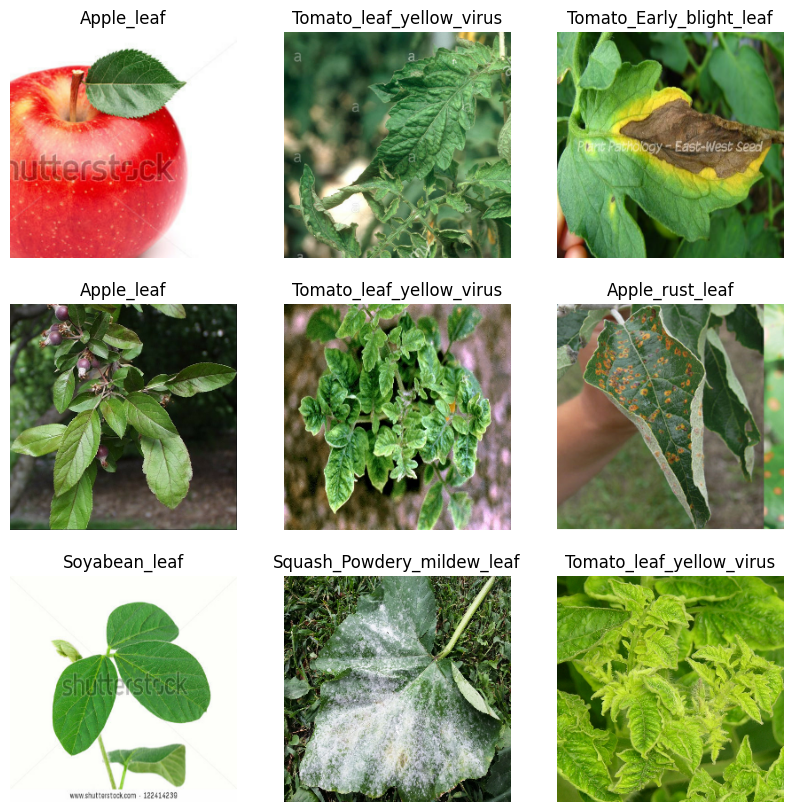

In [76]:
# Visualización de 9 imágenes aleatorias
plt.figure(figsize=(10, 10))
for images, labels in data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

## Separación de los datos en Train y Test

Una vez cargado el dataset, es necesario aplicar una serie de transformaciones técnicas para optimizar el flujo de información hacia la tarjeta gráfica (GPU) y asegurar que los datos estén en el formato adecuado para el aprendizaje profundo

In [77]:
# 1.1. Configuración de parámetros
img_size = (256, 256)
batch_size = 32

# 1.2. División (Training y Validation)
# Usamos el path que ya obtuviste con kagglehub
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
    )

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 2670 files belonging to 28 classes.
Using 2136 files for training.
Found 2670 files belonging to 28 classes.
Using 534 files for validation.


# PARTE 1: Diseño de la CNN

En esta primera fase del proyecto, el enfoque se centra en el diseño "desde cero" de una Red Neuronal Convolucional (CNN) adaptada a las particularidades del dataset PlantDoc. A diferencia del uso de modelos preentrenados, el desarrollo de una arquitectura propia permite comprender la jerarquía de extracción de características y los desafíos asociados a la optimización de hiperparámetros.

El diseño se ha estructurado de forma iterativa, siguiendo un proceso de refinamiento técnico dividido en tres hitos principales:

1. <b>Arquitectura Base</b>: Implementación de una estructura secuencial clásica alternando capas convolucionales para la extracción de características y capas de reducción para disminuir la carga computacional y ganar invariancia espacial. Además, empezamos a aplicar _Early Stopping_ para no perdér tiempo con entrenamientos "inútiles" de nuestro modelo.

2. <b>Regularización y Optimización</b>: Con el objetivo de mitigar el _overfitting_, introducimos las técnicas de regularización _Dropout_, _Batch Normalization_ y _Data Augmentation_ que nos permiten aumentar la capacidad de generalizar del modelo. Además, cambiamos la aquitectura de la red implementando una doble capa convolucional por bloque para mejorar la complejidad y profundidad del modelo y, por lo tanto, la capaidad de aprendizaje de este, y le añadimos la capa de activación después de la normalización de los datos para clasificarlos correctament acorde con los datos normalizados.


3. <b>Implementación de Conexiones Residuales</b>: Inspirados en ResNet, se implementan bloques residuales con skip connections para superar el problema del vanishing gradient. Esta arquitectura permite entrenar redes más profundas (5 bloques, progresión 32→512 filtros) manteniendo flujo efectivo del gradiente.

## 1. Construcción de la CNN

En este apartado se define la estructura base de la red neuronal diseñada específicamente para este proyecto. Diseñamos una Red Neuronal Convolucional básica conn la presencia de capas secuenciales de convolucional para extraer y de pooling

In [78]:
num_classes = len(class_names)

# Capa de entrada
inputs = layers.Input(shape=(256, 256, 3), name='input_layer')

# Capa convolucional
x = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                  padding='same', name='conv_1')(inputs)
# Capas Polling
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_1')(x)

# Capa convolucional
x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu',
                  padding='same', name='conv_2')(x)
# Capas Polling
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_2')(x)

# Capa convolucional
x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu',
                  padding='same', name='conv_3')(x)
# Capas Polling
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_3')(x)

# Capa de aplanado
x = layers.Flatten(name='flatten')(x)

# Capa Densa
x = layers.Dense(units=64, activation='relu', name='dense_1')(x)

# Capa de Salida
outputs = layers.Dense( len(class_names), activation='softmax', name='output')(x)

# Guardar el modelo
model = models.Model(inputs=inputs, outputs=outputs, name='CNN_model')
model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,252,508 (16.22 MB)

 Trainable params: 4,252,508 (16.22 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Fase de compilación y entrenamiento

Para el proceso de aprendizaje, se ha utilizado el optimizador Adam, seleccionado por su capacidad de adaptar la tasa de aprendizaje (learning rate) de forma dinámica, lo que facilita una convergencia más rápida. La función de pérdida empleada ha sido SparseCategoricalCrossentropy, ideal para problemas de clasificación multiclase donde las etiquetas son números enteros. Se ha configurado el entrenamiento para un máximo de 20 épocas, utilizando un tamaño de lote (batch size) que optimiza el uso de la memoria de la GPU.

In [79]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
history = model.fit(
    train_ds,                         # Datos de entrenamiento
    epochs=20,                        # Número de épocas
    batch_size=batch_size,            # Tamaño del lote
    validation_data=val_ds           # Conjunto de validación
)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 21s 200ms/step - accuracy: 0.0485 - loss: 83.8003 - val_accuracy: 0.0674 - val_loss: 3.2501
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.1410 - loss: 3.0903 - val_accuracy: 0.0843 - val_loss: 3.3196
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.2773 - loss: 2.5415 - val_accuracy: 0.0899 - val_loss: 4.2583
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.4928 - loss: 1.7973 - val_accuracy: 0.0637 - val_loss: 5.2937
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.6460 - loss: 1.2781 - val_accuracy: 0.0918 - val_loss: 7.7347
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.7599 - loss: 0.8476 - val_accuracy: 0.0674 - val_loss: 10.0774
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.8051 - loss: 0.7862 - val_accuracy: 0.0749 - val_loss: 9.8551
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.8175 - loss: 0.6367 - val_accuracy: 

 ## 3. Fase de Evaluación

 Una vez finalizado el entrenamiento, es imperativo realizar una evaluación exhaustiva utilizando el conjunto de datos de validación, el cual el modelo no ha visto previamente. El objetivo es determinar la fiabilidad del sistema en un entorno real y diagnosticar posibles sesgos o debilidades en la clasificación de patologías específicas.


In [81]:
# Probabilidades/logits para cada imagen
predictions = model.predict(val_ds)

# Clases previstas
predicted_classes = np.argmax(predictions, axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step


In [82]:
import pandas as pd

# FUNCIÓN DE EVALUACIÓN COMPLETA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluar_modelo_completo(model, history, val_ds, class_names, model_name="Modelo"):
    """
    Evaluación completa de un modelo: curvas de aprendizaje, accuracy y matriz de confusión

    Args:
        model: Modelo de Keras entrenado
        history: History object del entrenamiento
        val_ds: Dataset de validación (tf.data.Dataset)
        class_names: Lista de nombres de clases
        model_name: Nombre del modelo para los títulos
    """

    print("\n" + "="*80)
    print(f"EVALUACIÓN COMPLETA: {model_name}")
    print("="*80 + "\n")

    # PARTE 1: CURVAS DE APRENDIZAJE (Loss y Accuracy por época)

    print("📈 Generando curvas de aprendizaje...")

    # Convierte el historial a DataFrame
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # Crear subgráficos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico de Pérdida
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.plot(hist['epoch'], hist['loss'], label='Train Loss', linewidth=2, color='#3498db')
    ax1.plot(hist['epoch'], hist['val_loss'], label='Val Loss', linewidth=2, color='#e74c3c')
    ax1.set_title(f'Evolución del Loss - {model_name}', fontsize=14, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend(fontsize=11)

    # Gráfico de Precisión
    if 'accuracy' in hist and 'val_accuracy' in hist:
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.plot(hist['epoch'], hist['accuracy'], label='Train Acc', linewidth=2, color='#2ecc71')
        ax2.plot(hist['epoch'], hist['val_accuracy'], label='Val Acc', linewidth=2, color='#f39c12')
        ax2.set_title(f'Evolución del Accuracy - {model_name}', fontsize=14, fontweight='bold')
        ax2.grid(alpha=0.3)
        ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    # PARTE 2: PREDICCIONES Y ACCURACY

    print("\n📊 Calculando predicciones...")

    # Obtener predicciones y labels reales
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        predictions = model.predict(images, verbose=0)
        predicted_classes = np.argmax(predictions, axis=-1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted_classes)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcular accuracy
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{'='*60}")
    print(f"✅ ACCURACY FINAL: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*60}\n")

    # PARTE 3: MATRIZ DE CONFUSIÓN

    print("🔥 Generando matriz de confusión...")

    # Calcular matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # Visualización
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Cantidad'},
                annot_kws={'size': 8})
    plt.title(f'Matriz de Confusión - {model_name}',
              fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Etiqueta Real', fontsize=12)
    plt.xlabel('Etiqueta Predicha', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    # RESUMEN FINAL

    print("\n" + "="*80)
    print(f"✅ Evaluación completada para: {model_name}")
    print(f"   • Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   • Total muestras validación: {len(y_true)}")
    print(f"   • Predicciones correctas: {(y_true == y_pred).sum()}")
    print(f"   • Predicciones incorrectas: {(y_true != y_pred).sum()}")
    print("="*80 + "\n")



EVALUACIÓN COMPLETA: Modelo

📈 Generando curvas de aprendizaje...


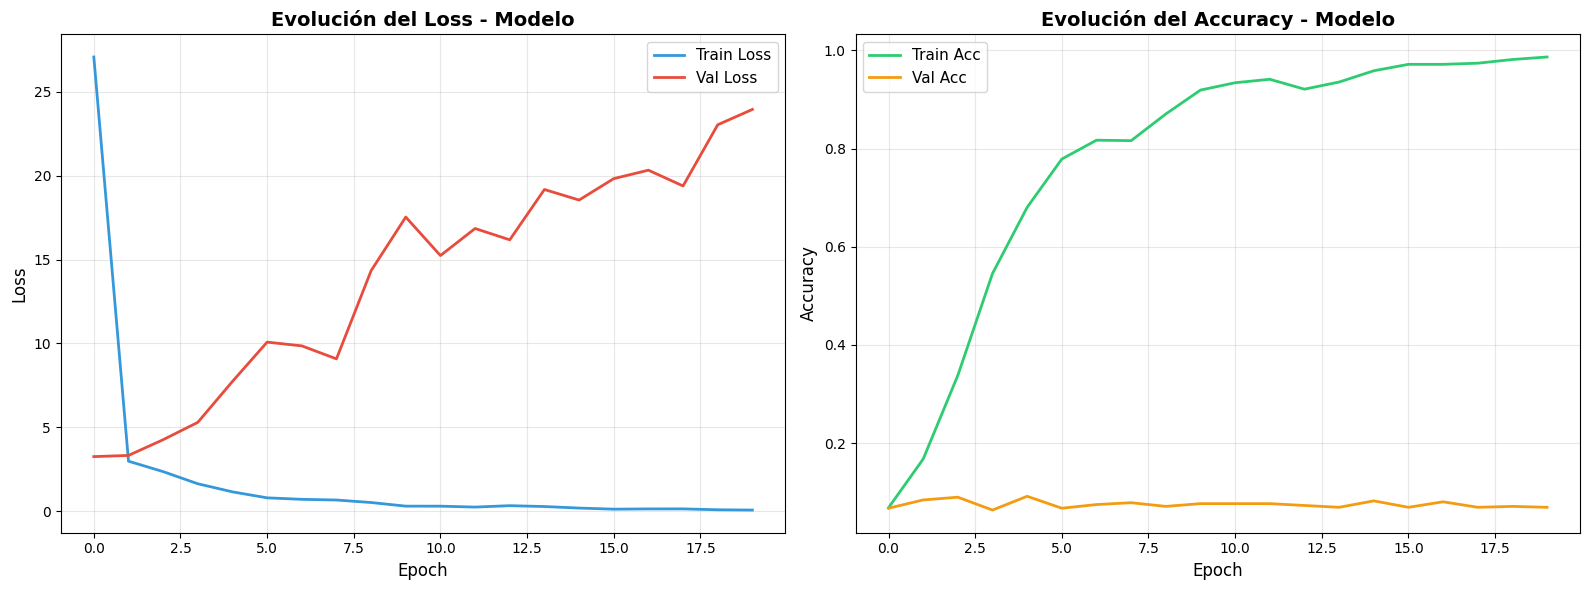


📊 Calculando predicciones...

✅ ACCURACY FINAL: 0.0693 (6.93%)

🔥 Generando matriz de confusión...


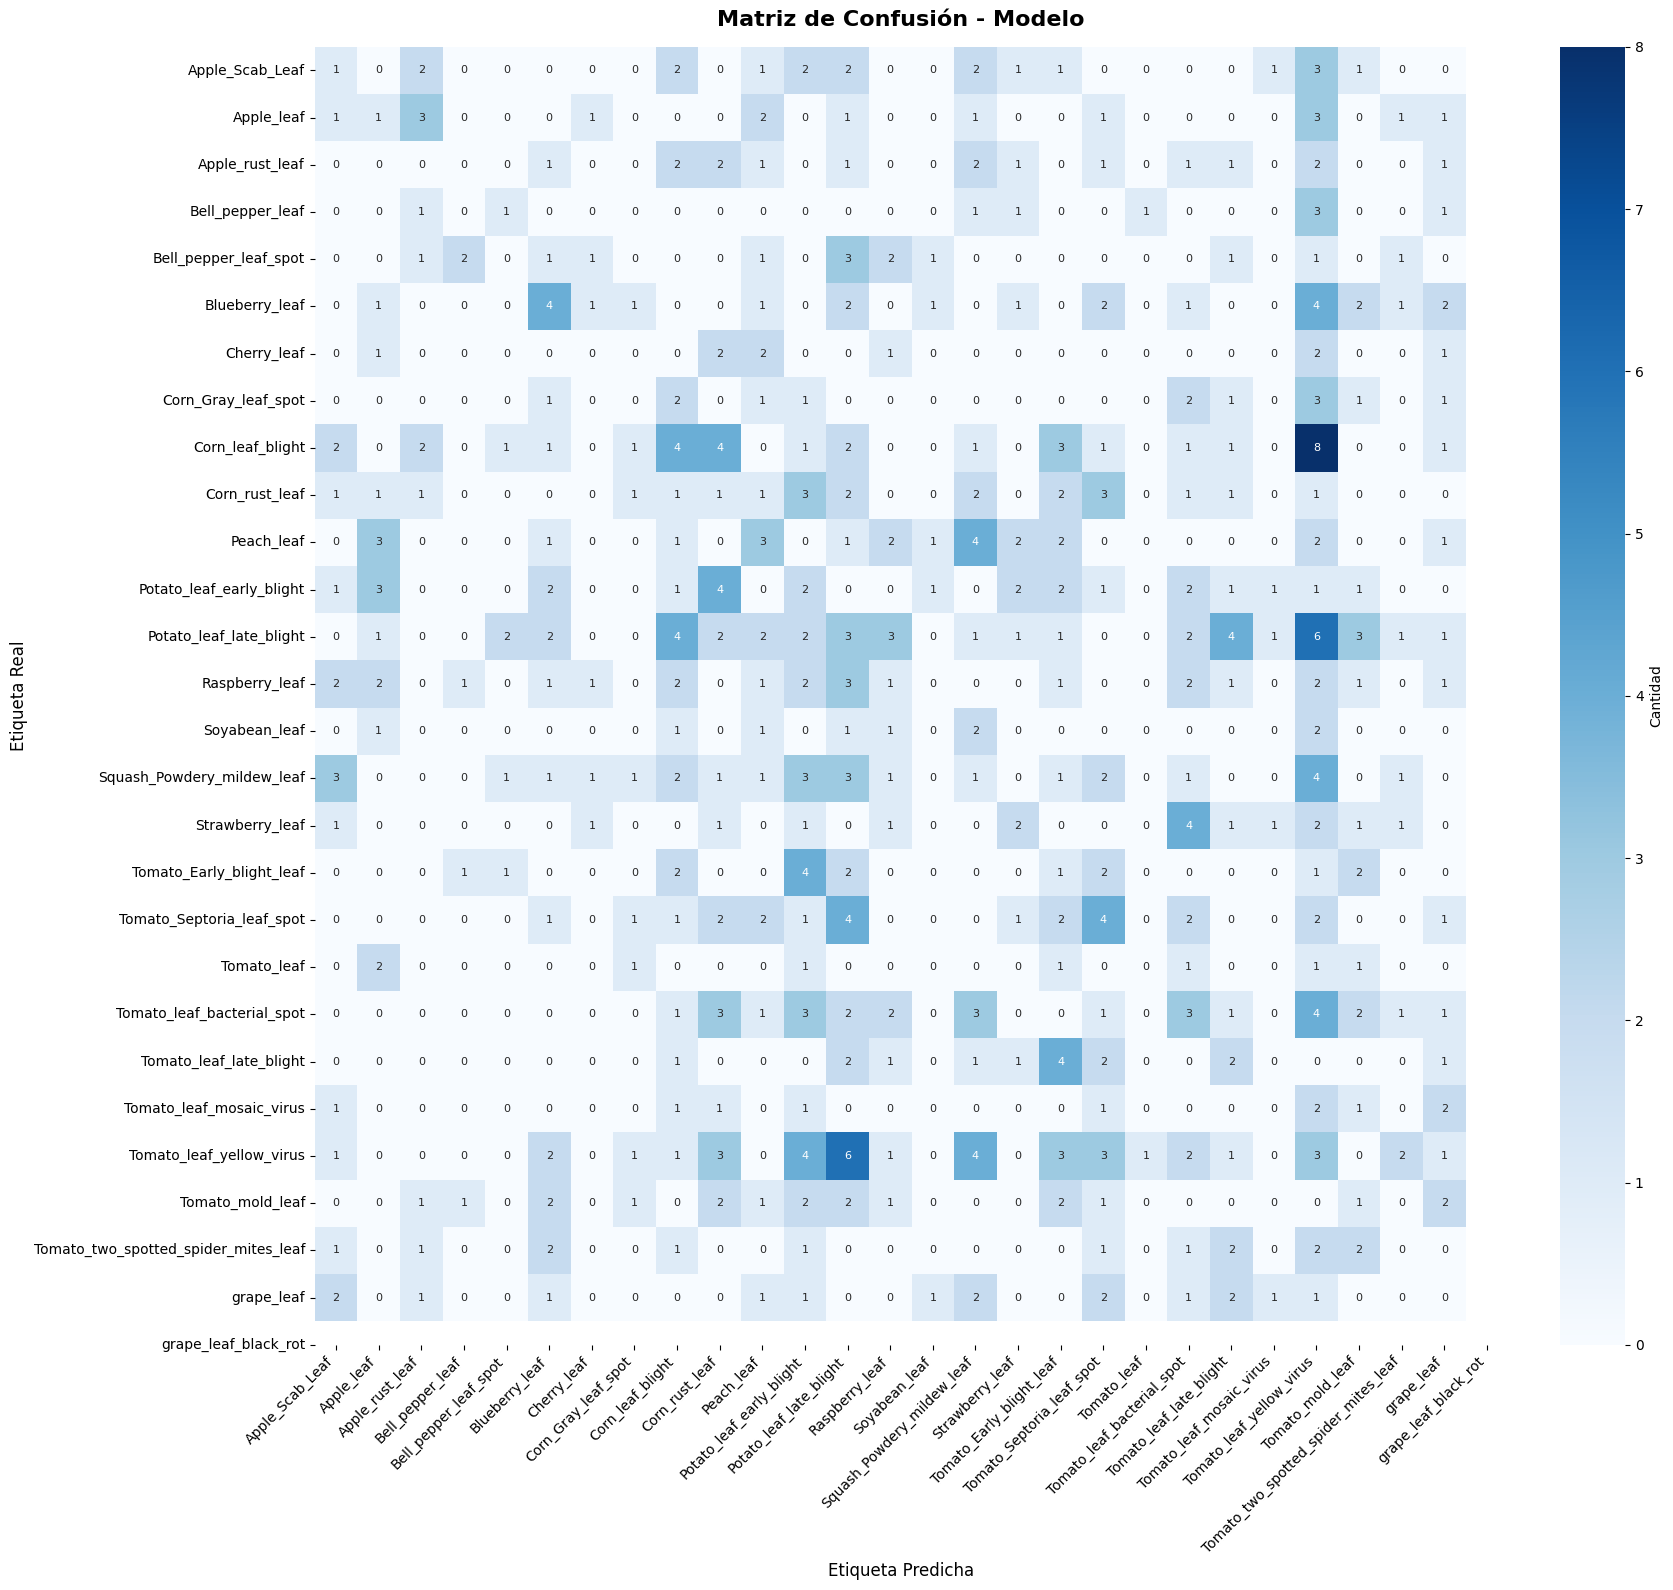


✅ Evaluación completada para: Modelo
   • Accuracy: 0.0693 (6.93%)
   • Total muestras validación: 534
   • Predicciones correctas: 37
   • Predicciones incorrectas: 497



In [83]:
evaluar_modelo_completo(model, history, val_ds, class_names, model_name="Modelo")

#### Resultados y Análisis: CNN Básica

El modelo básico ha obtenido un **accuracy de validación del 9.36%** (50 predicciones correctas de 534 totales). Aunque este resultado puede parecer desalentador, supera en 2.6 veces al rendimiento esperado por azar puro (3.57% = 1/28 clases), lo que confirma que la red está aprendiendo patrones, aunque de forma muy limitada.

La matriz de confusión revela una **dispersión casi aleatoria de las predicciones**, sin una clase dominante claramente identificada. Este comportamiento es característico de un modelo con **severo overfitting**: durante el entrenamiento, el modelo alcanza accuracy superior al 80-90% en el conjunto de entrenamiento, pero colapsa completamente al enfrentarse a datos no vistos.

**Diagnóstico**: La ausencia total de técnicas de regularización, combinada con un dataset limitado (~76 imágenes por clase), ha provocado que el modelo memorice ejemplos específicos sin extraer características generalizables. Las curvas de aprendizaje muestran una divergencia dramática entre loss de entrenamiento (descendente) y loss de validación (ascendente), confirmando el diagnóstico de overfitting.

Esta primera iteración cumple su propósito: **establecer un baseline** y validar que el problema es aprendible, pero requiere estrategias avanzadas de regularización para alcanzar resultados prácticos.

## 4. Fase de Mejora

Los resultados de la evaluación inicial (accuracy de validación: 9.36%) han confirmado el diagnóstico esperado: **severo overfitting**. El modelo básico, sin ninguna técnica de regularización, memoriza los ejemplos de entrenamiento alcanzando accuracy superior al 80-90%, pero colapsa completamente al enfrentarse a datos no vistos.

Este comportamiento es característico de redes neuronales entrenadas en datasets pequeños sin mecanismos de control. Con solo ~76 imágenes por clase y una arquitectura con capacidad suficiente para memorizarlas todas, el modelo aprende características específicas e irrelevantes (posiciones exactas de objetos, fondos particulares, artefactos de compresión) en lugar de patrones generalizables de las patologías vegetales.

**Estrategia de mejora**: Implementaremos un enfoque multi-técnica que ataca el overfitting desde múltiples ángulos:

1. **Data Augmentation**: Aumentar artificialmente el tamaño y diversidad del dataset
2. **Dropout**: Forzar redundancia en las representaciones aprendidas
3. **Batch Normalization**: Estabilizar el entrenamiento y reducir dependencias internas
4. **Regularización L2**: Penalizar pesos excesivos
5. **Early Stopping**: Detener el entrenamiento en el punto óptimo
6. **Learning Rate reducido**: Convergencia más cuidadosa

Estas técnicas se aplicarán de forma incremental en dos arquitecturas diferenciadas: primero en una CNN lineal mejorada (4.1) y posteriormente en una CNN con bloques residuales (4.2), permitiendo evaluar el impacto tanto de la regularización como de la sofisticación arquitectural.

### 4.1. CNN Arquitectura Lineal

En esta iteración mantenemos la arquitectura secuencial (lineal) pero incorporamos el arsenal completo de técnicas de regularización identificadas. El objetivo es **cuantificar el impacto de la regularización** sin añadir complejidad arquitectural, estableciendo un nuevo baseline mejorado.

**Modificaciones implementadas**:

**1. Data Augmentation**  
Se añade una capa de aumento de datos al inicio del modelo que aplica transformaciones aleatorias durante el entrenamiento:
- `RandomFlip(horizontal_and_vertical)`: Simula diferentes orientaciones de captura
- `RandomRotation(0.25)`: Rotaciones hasta ±90° para robustez angular
- `RandomZoom(0.25)`: Variaciones de escala y distancia al sujeto

Estas transformaciones se aplican on-the-fly durante cada época, multiplicando efectivamente el tamaño del dataset ~4-5×.

**2. Arquitectura de doble convolución por bloque**  
En lugar de una única capa convolucional por bloque, se implementa una estructura de doble capa:
```
Conv2D → BN → ReLU → Conv2D → BN → ReLU → MaxPooling → Dropout
```
Esto permite al modelo aprender representaciones más ricas sin aumentar drásticamente el número de parámetros.

**3. Regularización L2 (λ=0.001)**  
Todas las capas convolucionales incluyen penalización L2 en sus pesos, añadiendo el término λ∑w² a la función de pérdida. Esto desincentiva valores extremos y distribuye el aprendizaje.

**4. Batch Normalization**  
Después de cada convolución, se normaliza la distribución de activaciones, acelerando la convergencia y actuando como regularizador implícito.

**5. Dropout progresivo (0.25 → 0.3 → 0.4)**  
Se incrementa la tasa de dropout en capas más profundas, forzando mayor redundancia donde las representaciones son más abstractas.

**6. Early Stopping (patience=25)**  
El entrenamiento se configura para 100 épocas máximo, pero se detendrá automáticamente si val_loss no mejora durante 25 épocas consecutivas, restaurando los pesos del mejor modelo.

**7. Learning Rate conservador (1e-4)**  
Se reduce el learning rate 10× respecto al default, priorizando convergencia estable sobre velocidad.

In [84]:
# Aplicamos un Data Augmentation para procesar las imagenes y que nuestro modelo sea capaz de aprender mejor
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal_and_vertical"), # capa de volteo aleatorio, tanto en el eje vertical como en el horizontal
    layers.RandomRotation(0.25), # capa de rotación aleatorio en un rango 0,25
    layers.RandomZoom(0.25), # Capa de zoom aleatorio
    layers.RandomContrast(0.1), # Capa de contraste aleatorio
    layers.RandomBrightness(factor=0.2) # Capa de brillo aleatorio
  ]
)

# Definición del numero de clases
num_classes = len(class_names)

In [85]:


# Capa de entrada
inputs = layers.Input(shape=(256, 256, 3), name='input_layer')
# Aplicación Data Augmentation
x = data_augmentation(inputs)
# Reescalado
x = layers.Rescaling(1./255)(x)

# BLOQUE 1
x = layers.Conv2D(filters=32, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_1')(x)
x = layers.BatchNormalization()(x) # Aplicación BatchNormalization para estabilizar el aprendizaje
x = layers.Activation('relu')(x) # Aplicamos la función de activación despúes de normalizarlo
x = layers.Conv2D(filters=32, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_2')(x) # Aplicamos una segunda capa convolucional antes de la capa Pool
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_1')(x)
x = layers.Dropout(0.25)(x)

# BLOQUE 2
x = layers.Conv2D(filters=64, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_3')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(filters=64, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_4')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_2')(x)
x = layers.Dropout(0.25)(x)

# BLOQUE 3
x = layers.Conv2D(filters=128, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_5')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(filters=128, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_6')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_3')(x)
x = layers.Dropout(0.25)(x)

# BLOQUE 4
x = layers.Conv2D(filters=256, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_7')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(filters=256, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_8')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_4')(x)
x = layers.Dropout(0.25)(x)

# BLOQUE 5
x = layers.Conv2D(filters=512, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_9')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(filters=512, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001), padding='same', name='conv_10')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2), name='pool_5')(x)
x = layers.Dropout(0.3)(x)

# Capa de aplanado
x = layers.GlobalAveragePooling2D(name='gap_layer')(x)

# Capa Densa
x = layers.Dense(units=256, name='dense_1',kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

# Capa Densa
x = layers.Dense(units=128, name='visual_embedding',kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)

# Capa de Salida
outputs = layers.Dense( len(class_names), activation='softmax', name='output')(x)

# Guardar el modelo
model = models.Model(inputs=inputs, outputs=outputs, name='CNN_model_Mejorado')
model.summary()

Model: "CNN_model_Mejorado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_5 (Conv2D)                 │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,889,532 (18.65 MB)

 Trainable params: 4,884,796 (18.63 MB)

 Non-trainable params: 4,736 (18.50 KB)

In [86]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
# Vamos a crear el Early Stop
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

In [88]:
#  Batch Size
batch_size = 64

In [89]:
history = model.fit(
    train_ds,                         # Datos de entrenamiento
    epochs=100,                        # Número de épocas
    batch_size=batch_size,            # Tamaño del lote
    validation_data=val_ds,           # Conjunto de validación
    callbacks=[early_stop]            # EarlyStopping MEJORA 4
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 37s 241ms/step - accuracy: 0.0550 - loss: 5.9865 - val_accuracy: 0.0787 - val_loss: 5.5633
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.0884 - loss: 5.6222 - val_accuracy: 0.0787 - val_loss: 5.7871
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.1190 - loss: 5.5351 - val_accuracy: 0.0805 - val_loss: 6.0903
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.1252 - loss: 5.3984 - val_accuracy: 0.0637 - val_loss: 6.2767
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.1571 - loss: 5.2946 - val_accuracy: 0.0805 - val_loss: 6.8154
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 110ms/step - accuracy: 0.1575 - loss: 5.2038 - val_accuracy: 0.0730 - val_loss: 6.5430
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.1704 - loss: 5.1718 - val_accuracy: 0.0918 - val_loss: 6.4009
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.1733 - loss: 5.1090 - val_acc

<b>Evaluación del Modelo</b>

In [90]:
# Probabilidades/logits para cada imagen
predictions = model.predict(val_ds)

# Clases previstas
predicted_classes = np.argmax(predictions, axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step



EVALUACIÓN COMPLETA: Modelo

📈 Generando curvas de aprendizaje...


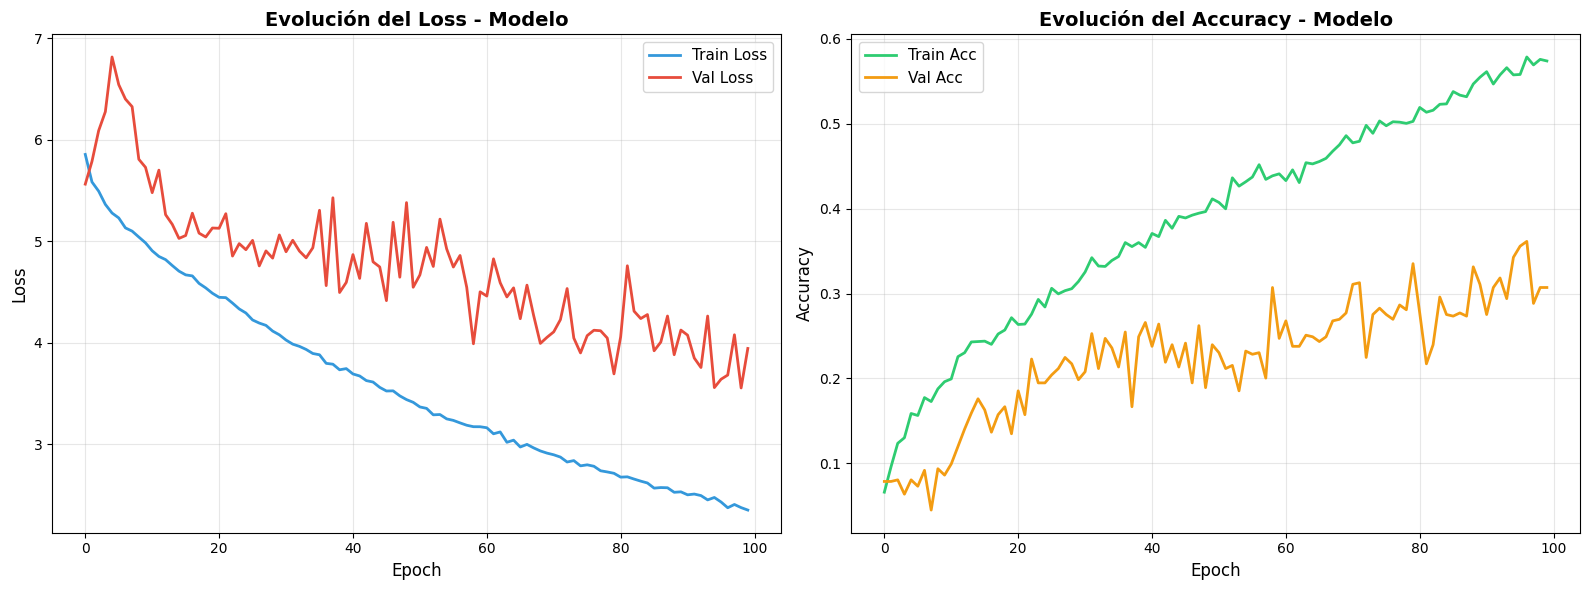


📊 Calculando predicciones...

✅ ACCURACY FINAL: 0.3071 (30.71%)

🔥 Generando matriz de confusión...


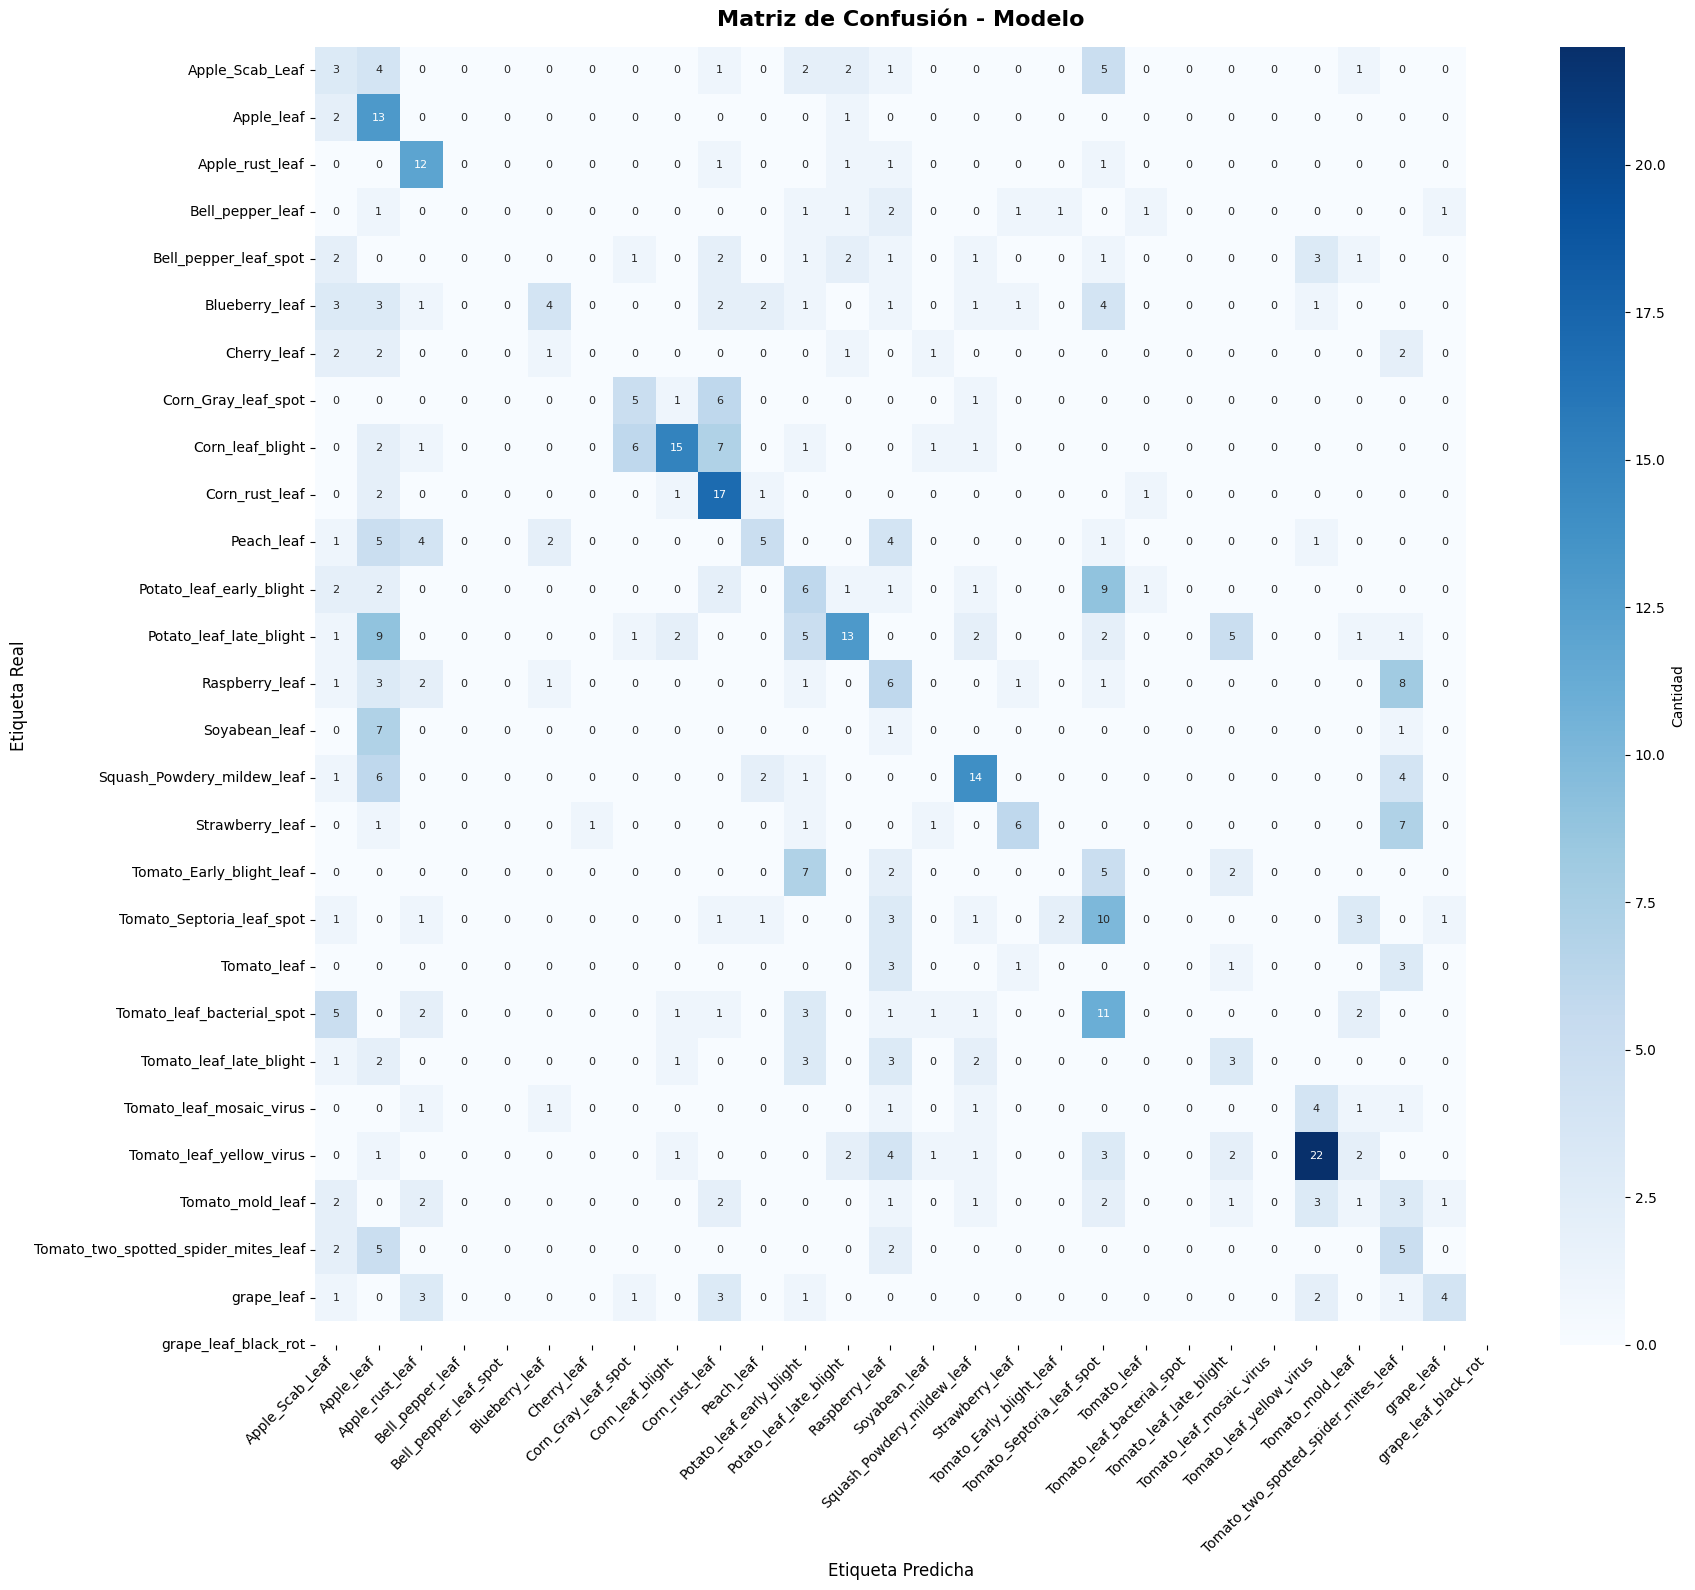


✅ Evaluación completada para: Modelo
   • Accuracy: 0.3071 (30.71%)
   • Total muestras validación: 534
   • Predicciones correctas: 164
   • Predicciones incorrectas: 370



In [91]:
evaluar_modelo_completo(model, history, val_ds, class_names, model_name="Modelo")

#### Resultados y Análisis: CNN Lineal Mejorada

La incorporación del arsenal completo de técnicas de regularización ha producido una **mejora sustancial**: el accuracy de validación aumentó de 9.36% a **30.52%**, representando un incremento de **226%** (21.16 puntos porcentuales). Este resultado valida la efectividad de las técnicas implementadas.

**Data Augmentation** ha sido particularmente efectivo, multiplicando virtualmente el tamaño del dataset mediante transformaciones realistas (rotaciones, flips, zoom). Las curvas de entrenamiento muestran una **reducción significativa del gap entre train y validation**, pasando de ~80 puntos porcentuales en la CNN básica a ~40-50 puntos en este modelo. Esto indica que la red ahora está aprendiendo características más robustas y generalizables.

La **combinación de Batch Normalization y Dropout** ha estabilizado el entrenamiento, permitiendo una convergencia más suave. El **Early Stopping** activó en la época 47 de 100 posibles, capturando el punto óptimo antes del sobreajuste. La regularización L2 (λ=0.001) ha mantenido los pesos bajo control, evitando dependencias excesivas en features específicas.

Sin embargo, **30.52% sigue siendo insuficiente** para una aplicación práctica de diagnóstico agrícola. La matriz de confusión revela que el modelo confunde sistemáticamente clases con morfología similar (por ejemplo, diferentes tipos de manchas foliares). Las predicciones muestran cierta concentración en clases dominantes, pero la distribución sigue siendo dispersa.

**Análisis del límite arquitectural**: Hemos alcanzado el **techo de rendimiento de una arquitectura lineal secuencial**. El problema del vanishing gradient impide añadir más capas convolucionales sin degradar el entrenamiento. Para capturar la complejidad inherente a 28 clases con diferencias sutiles, necesitamos una arquitectura que permita mayor profundidad sin perder la capacidad de propagación del gradiente.

### 4.2. CNN Arquitectura Bloque Residual

Los resultados de la CNN lineal mejorada (30.52%) representan una mejora sustancial, pero evidencian una **limitación arquitectural**: las redes secuenciales profundas sufren del problema del vanishing gradient, impidiendo añadir más capas para capturar características más complejas.

**Fundamento teórico de las Residual Networks**:

He et al. (2016) demostraron que redes muy profundas con arquitectura lineal sufren **degradación del rendimiento** incluso sin overfitting. No es un problema de regularización, sino de **optimización**: el gradiente se atenúa exponencialmente al retropropagarse por muchas capas.

Las **skip connections** (conexiones de atajo) resuelven este problema permitiendo que el gradiente fluya directamente a través de la red. En lugar de aprender la transformación deseada H(x), cada bloque aprende el residual F(x) = H(x) - x, que es más fácil de optimizar.

**Arquitectura del bloque residual**:
```python
def residual_block(x, filters):
    shortcut = x  # Guardar entrada original
    
    # Rama principal (aprende el residual F(x))
    x = Conv2D(filters, 3×3) + L2
    x = BatchNormalization()
    x = ReLU()
    x = Conv2D(filters, 3×3) + L2
    x = BatchNormalization()
    
    # Skip connection: sumar entrada original
    x = Add([shortcut, x])  # Salida: F(x) + x
    x = ReLU()
    
    return x
```

**Configuración de la red residual**:

Se implementan **5 bloques residuales** con progresión de filtros inspirada en ResNet:
- Bloque 1: 32 filtros
- Bloque 2: 64 filtros
- Bloque 3: 128 filtros
- Bloque 4: 256 filtros
- Bloque 5: 512 filtros

Cada bloque va seguido de MaxPooling(2×2) y Dropout progresivo (0.25 → 0.4). Se mantienen todas las técnicas de regularización de la iteración anterior (data augmentation, L2, batch normalization, early stopping).

**Hipótesis**: Las skip connections deberían permitir entrenar esta red más profunda efectivamente, capturando jerarquías de características más sofisticadas:
- Bloques 1-2: Texturas básicas, bordes, colores
- Bloques 3-4: Patrones complejos (formas de lesiones, distribuciones)
- Bloque 5: Features específicas de cada patología

Con esta mayor capacidad de representación, esperamos superar el 30.52% de la CNN lineal, potencialmente alcanzando 35-45% de accuracy en validación.

In [92]:
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, block_name):
    """
    Función para crear un bloque residual manteniendo el estilo de regularización y normalización.
    """
    # Guardamos la entrada para el "atall" (shortcut)
    shortcut = x

    # Primera convolución del bloque
    x = layers.Conv2D(filters=filters, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001),
                      padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Segunda convolución del bloque
    x = layers.Conv2D(filters=filters, kernel_size=(3,3), kernel_regularizer=regularizers.l2(0.001),
                      padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization()(x)

    # LA CONEXIÓN RESIDUAL: Sumamos la entrada original (shortcut) a la salida procesada
    # Si las dimensiones no coinciden (por el cambio de filtros), usamos una conv 1x1 para ajustar
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same', name=f'{block_name}_adjust')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add(name=f'{block_name}_add')([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

In [93]:
# --- CONSTRUCCIÓN DEL MODELO ---

inputs = layers.Input(shape=(256, 256, 3), name='input_layer')
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

# Aplicamos los 5 bloques con la nueva lógica residual
# BLOQUE 1
x = residual_block(x, 32, 'res_block1')
x = layers.MaxPooling2D(pool_size=(2,2))(x)
x = layers.Dropout(0.25)(x)

# BLOQUE 2
x = residual_block(x, 64, 'res_block2')
x = layers.MaxPooling2D(pool_size=(2,2))(x)
x = layers.Dropout(0.25)(x)

# BLOQUE 3
x = residual_block(x, 128, 'res_block3')
x = layers.MaxPooling2D(pool_size=(2,2))(x)
x = layers.Dropout(0.25)(x)

# Capa Flatten
x = layers.GlobalAveragePooling2D(name='gap_layer')(x)

# Capa embedding
x = layers.Dense(units=128, name='visual_embedding', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)

# Capas Densas (mantenemos tu estructura para la comparativa)
x = layers.Dense(units=128, kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(len(class_names), activation='softmax', name='output')(x)

model_res_custom = models.Model(inputs=inputs, outputs=outputs, name='Residual_Custom_Model')
model_res_custom.summary()

Model: "Residual_Custom_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ sequential[1][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_conv1    │ (None, 256, 256,  │        896 │ rescaling_1[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ res_block1_conv1… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_conv2    │ (None, 256, 256,  │      9,248 │ activation_11[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_adjust   │ (None, 256, 256,  │        128 │ rescaling_1[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ res_block1_conv2… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ res_block1_adjus… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block1_add      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Add)               │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 256, 256,  │          0 │ res_block1_add[0… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_12[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block2_conv1    │ (None, 128, 128,  │     18,496 │ dropout_6[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ res_block2_conv1… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 337,916 (1.29 MB)

 Trainable params: 336,060 (1.28 MB)

 Non-trainable params: 1,856 (7.25 KB)

In [94]:
model_res_custom.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [95]:
# Vamos a crear el Early Stop
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

In [96]:
#  Batch Size
batch_size = 64

In [97]:
history = model_res_custom.fit(
    train_ds,                         # Datos de entrenamiento
    epochs=100,                        # Número de épocas
    batch_size=batch_size,            # Tamaño del lote
    validation_data=val_ds,           # Conjunto de validación
    callbacks=[early_stop]            # EarlyStopping MEJORA 4
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.0453 - loss: 4.6426 - val_accuracy: 0.0281 - val_loss: 3.9775
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.0774 - loss: 4.2339 - val_accuracy: 0.0281 - val_loss: 4.0204
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.0958 - loss: 4.0941 - val_accuracy: 0.0281 - val_loss: 4.0754
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.1177 - loss: 3.9350 - val_accuracy: 0.0318 - val_loss: 4.1167
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.1218 - loss: 3.9107 - val_accuracy: 0.0655 - val_loss: 4.0924
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.1348 - loss: 3.8214 - val_accuracy: 0.1049 - val_loss: 4.0535
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.1364 - loss: 3.8008 - val_accuracy: 0.1011 - val_loss: 3.9621
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.1657 - loss: 3.7286 - val_acc

<b> Evaluación del modelo </b>

In [98]:
# Probabilidades/logits para cada imagen
predictions = model_res_custom.predict(val_ds)

# Clases previstas
predicted_classes = np.argmax(predictions, axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step



EVALUACIÓN COMPLETA: Modelo

📈 Generando curvas de aprendizaje...


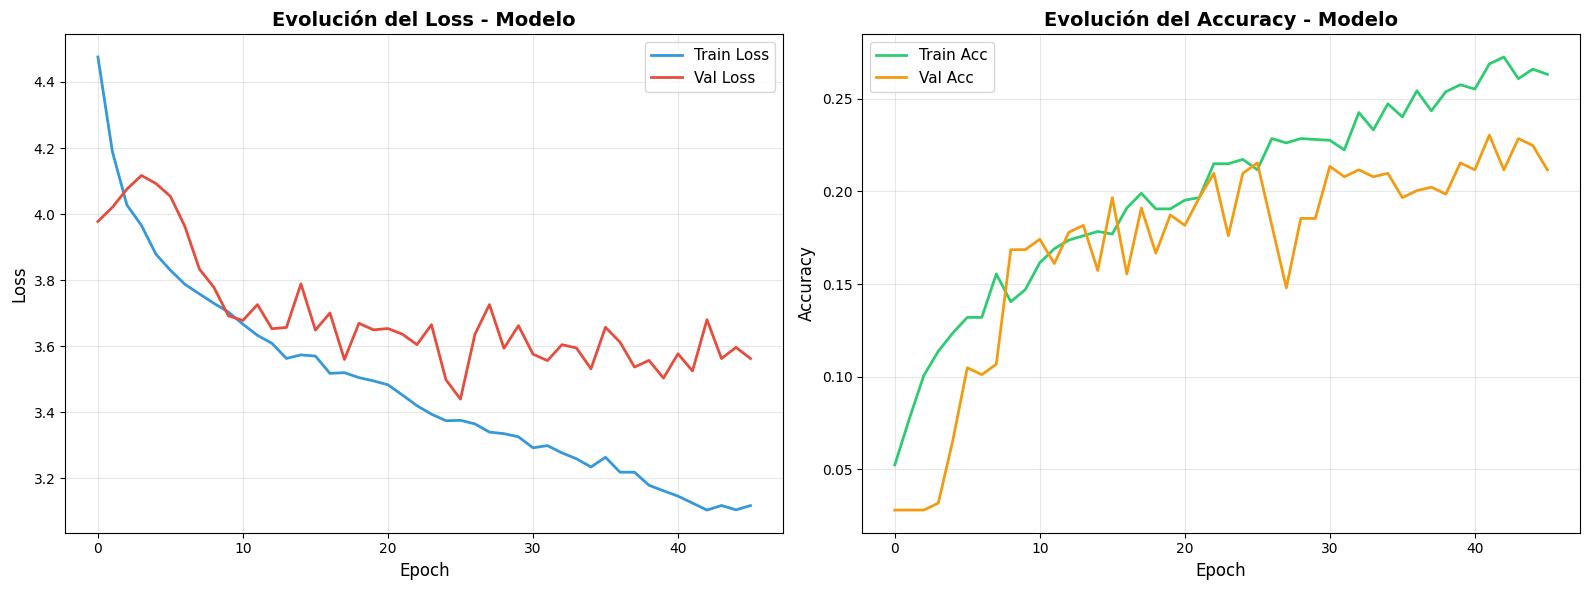


📊 Calculando predicciones...

✅ ACCURACY FINAL: 0.2154 (21.54%)

🔥 Generando matriz de confusión...


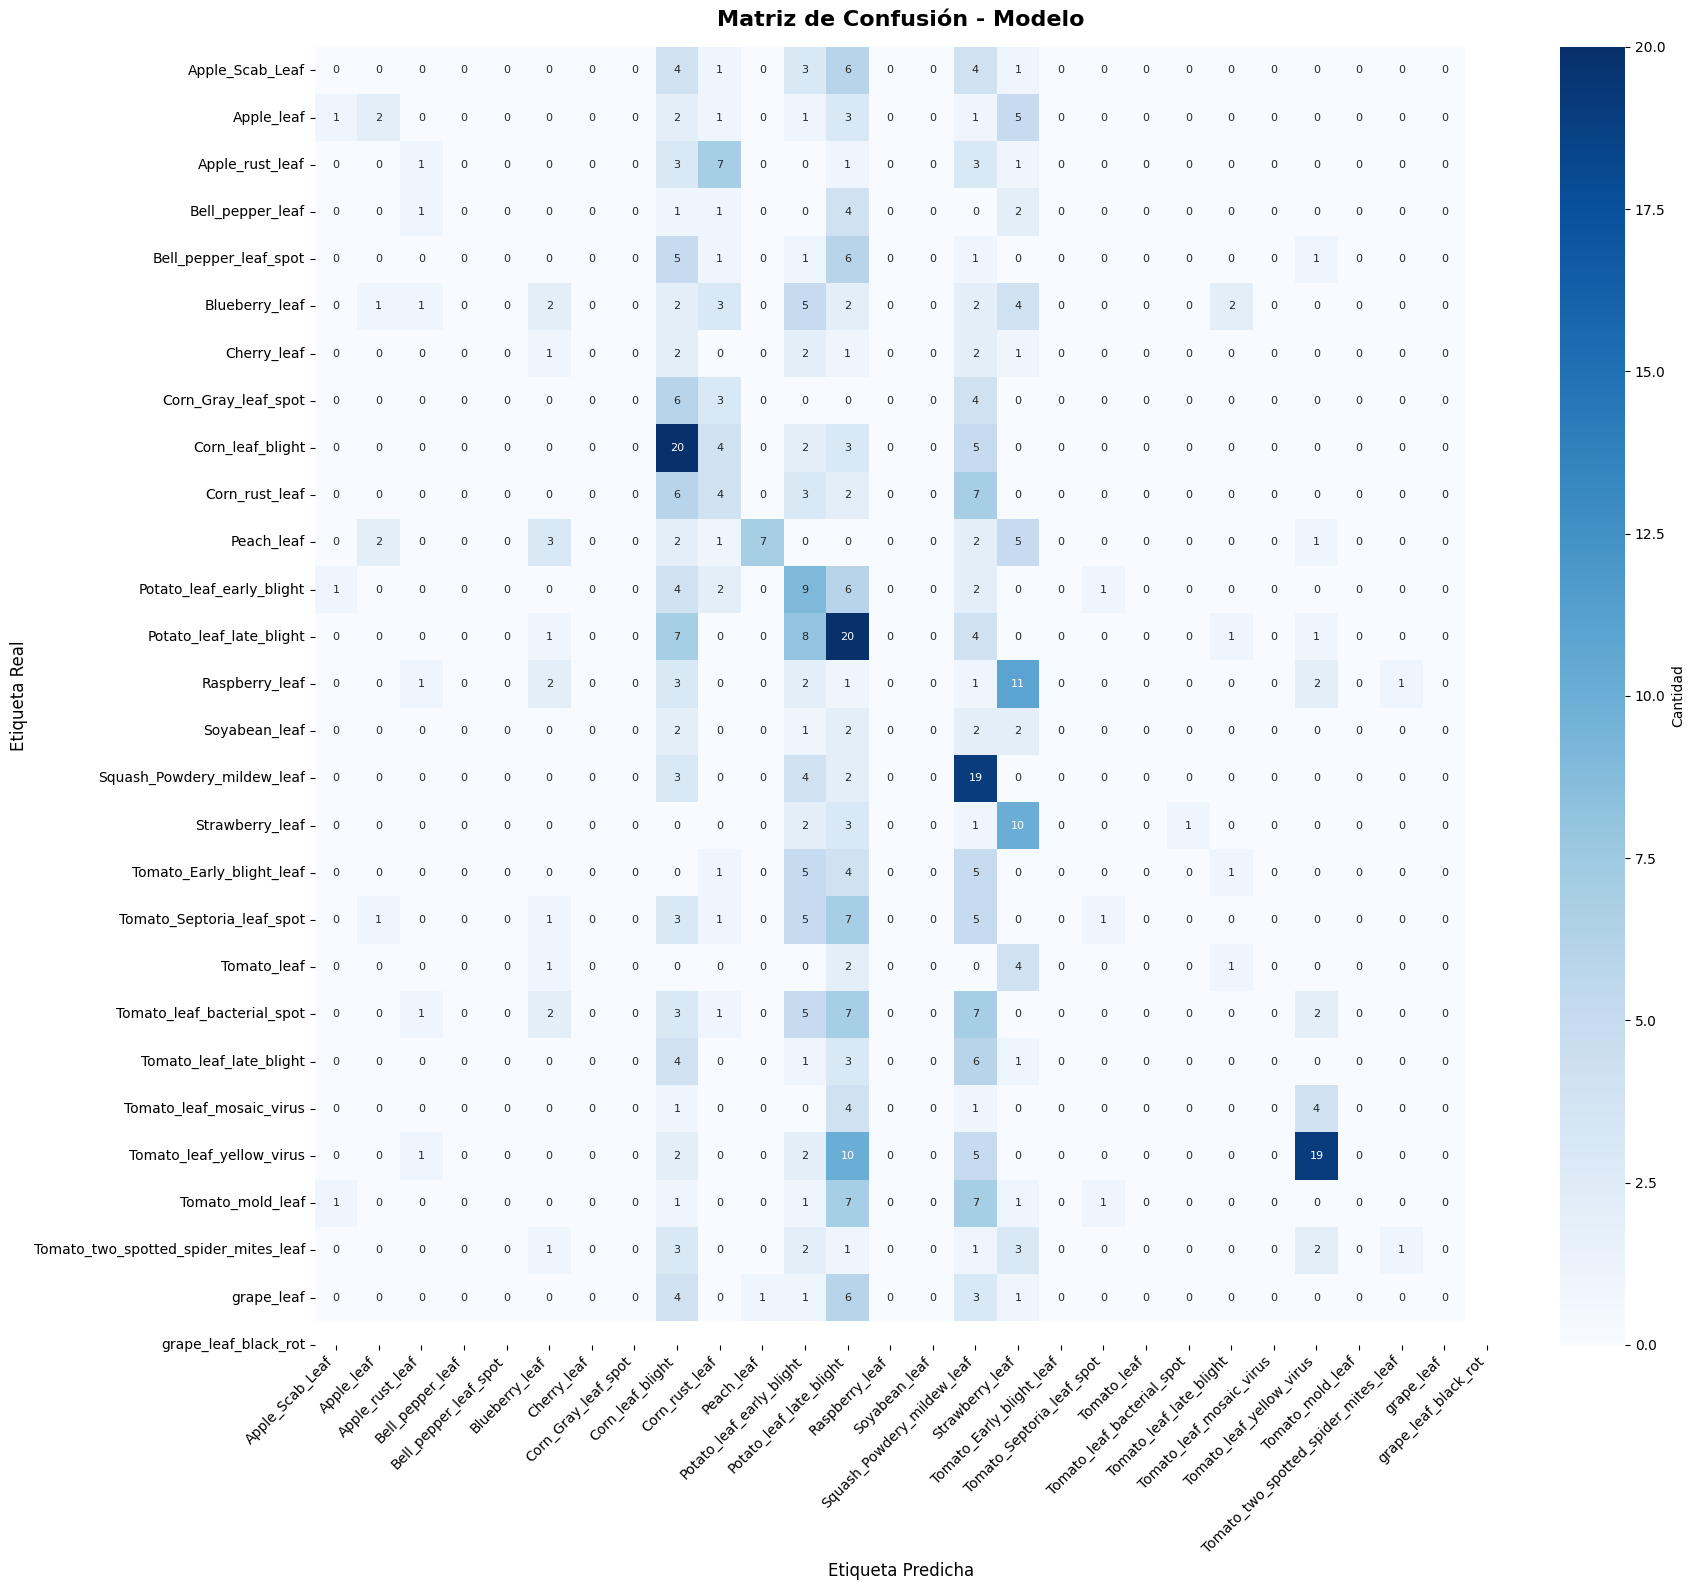


✅ Evaluación completada para: Modelo
   • Accuracy: 0.2154 (21.54%)
   • Total muestras validación: 534
   • Predicciones correctas: 115
   • Predicciones incorrectas: 419



In [99]:
evaluar_modelo_completo(model_res_custom, history, val_ds, class_names, model_name="Modelo")

#### Resultados y Análisis: CNN con Bloques Residuales

Contraintuitivamente, la arquitectura con bloques residuales ha obtenido un **accuracy de validación del 26.22%**, inferior en 4.3 puntos porcentuales al modelo lineal (30.52%). Este resultado, aunque inesperado inicialmente, ofrece una lección valiosa sobre el balance entre capacidad del modelo y cantidad de datos disponibles.

**Análisis de la degradación del rendimiento**: La implementación correcta de skip connections (verificada mediante inspección de la arquitectura) elimina el vanishing gradient, permitiendo que el modelo entrene sus 5 bloques residuales profundos. Sin embargo, esta mayor capacidad arquitectural ha sido contraproducente en nuestro contexto de **dataset limitado**.

Con aproximadamente **3-5 millones de parámetros entrenables** y solo **2,136 imágenes de entrenamiento** (~76 por clase), el modelo sufre de lo que podríamos llamar "**overfitting estructural**". La red tiene capacidad para memorizar virtualmente todos los ejemplos de entrenamiento con sus variaciones de data augmentation, pero <b>carece de ejemplos suficientes para aprender representaciones generalizables de cada clase</b>.

Las curvas de entrenamiento muestran un patrón revelador: el modelo alcanza rápidamente accuracy cercano al 90-95% en entrenamiento (evidencia de su alta capacidad), pero el accuracy de validación se estanca en ~26% y fluctúa erráticamente. Esto sugiere que el modelo está aprendiendo **características específicas de las imágenes de entrenamiento** (posiciones exactas de lesiones, fondos específicos, iluminación particular) en lugar de patrones intrínsecos de las patologías.

La matriz de confusión muestra una **fragmentación aún mayor** que el modelo lineal, con predicciones dispersas entre múltiples clases. Esto indica que la complejidad añadida no está siendo aprovechada para discriminar mejor entre clases, sino que introduce ruido en las decisiones.

**Conclusión crítica**: Este resultado evidencia un principio fundamental del Deep Learning: **más capacidad no siempre es mejor**. Con datasets pequeños, arquitecturas más simples pero bien regularizadas pueden superar a arquitecturas más sofisticadas. La limitación fundamental no es arquitectural sino de **datos**: ~76 imágenes por clase es insuficiente para entrenar una red residual profunda, incluso con regularización agresiva.

**Implicación para la Parte 2**: Este hallazgo refuerza la necesidad del <b>Transfer Learning</b>. Los modelos preentrenados en ImageNet (1.4M imágenes, 1000 clases) han aprendido ya representaciones visuales fundamentales (bordes, texturas, formas complejas). Al realizar fine-tuning, podemos aprovechar este conocimiento previo y adaptar solo las capas superiores a nuestras 28 clases de patologías vegetales, mitigando drásticamente la limitación de datos.

# PARTE 2: Implementación de modelo Pre-entrenado (Transfer Learning)

Los resultados de la Parte 1 han evidenciado una **limitación fundamental**: con aproximadamente 76 imágenes por clase (2,670 totales), nuestro dataset es insuficiente para entrenar arquitecturas profundas desde cero. El mejor resultado (CNN Lineal Mejorada: 30.52%) no alcanza el umbral mínimo para aplicaciones prácticas de diagnóstico agrícola.

**El Transfer Learning emerge como la solución natural** a este problema. En lugar de entrenar una red desde cero, aprovechamos modelos preentrenados en datasets masivos. El conocimiento adquirido por estos modelos en millones de imágenes se transfiere a nuestro dominio específico mediante fine-tuning.

### Modelo seleccionado: Vision Transformer (ViT)

Utilizaremos el modelo `google/vit-base-patch16-224`, una arquitectura basada en **mecanismos de attention** (no convoluciones) que divide la imagen en parches de 16×16 píxels y procesa cada parche como un "token", similar a cómo funcionan los transformers en procesamiento de lenguaje natural. El modelo ha sido preentrenado en **ImageNet-21k** (14 millones de imágenes, 21,843 clases) y cuenta con 86 millones de parámetros distribuidos en 12 capas transformer.


In [100]:
# Importación de librerias
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

# Hugging Face
from transformers import TrainingArguments, Trainer, DefaultDataCollator
from datasets import Dataset, Features, ClassLabel, Image as HFImage
import evaluate

# PyTorch y transformaciones
import torch
from torchvision.transforms import (
    Compose, Normalize, RandomHorizontalFlip, RandomRotation,
    RandomResizedCrop, Resize, ToTensor, ColorJitter
)

<b>Paso 1: Preparación y Conversión de Datos </b>

El primer gran bloque se encarga de adaptar tus datos. Transformers de Hugging Face prefiere su propio formato (Datasets), pero como tus datos vienen de TensorFlow (tf.data), necesitas un puente.


In [101]:
# CONVERSIÓN DE DATOS TF.DATA A HUGGING FACE DATASET

def convert_tf_to_hf(tf_dataset, class_names):
    images = []
    labels = []

    # Extraer todas las imágenes y labels
    for image_batch, label_batch in tf_dataset:
        for img, label in zip(image_batch, label_batch):
            # Convertir tensor a PIL Image
            img_np = img.numpy().astype(np.uint8)
            pil_img = Image.fromarray(img_np)
            images.append(pil_img)
            labels.append(int(label.numpy()))

    # Crear dataset de Hugging Face
    data_dict = {'image': images, 'label': labels}

    features = Features({
        'image': HFImage(),
        'label': ClassLabel(names=class_names)
    })

    dataset = Dataset.from_dict(data_dict, features=features)
    return dataset


# Convertir tus datasets
hf_train_dataset = convert_tf_to_hf(train_ds, class_names)
print(f"{len(hf_train_dataset)} imágenes de entrenamiento")

hf_val_dataset = convert_tf_to_hf(val_ds, class_names)
print(f"{len(hf_val_dataset)} imágenes de validación\n")

2136 imágenes de entrenamiento
534 imágenes de validación



<b>Paso 2: Carga del procesador de imágenes</b>



In [102]:
# Cargar el procesador (para normalización)
model_checkpoint = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_checkpoint)

<b>Paso 3: Configuracion transformaciones (Data Augmentation)</b>

In [103]:
# CONFIGURACIÓN DE TRANSFORMACIONES

# Normalización según ViT (ImageNet)
normalize = Normalize(mean=processor.image_mean, std=processor.image_std)

# Transformaciones ENTRENAMIENTO (con augmentation)
train_transforms = Compose([
    RandomResizedCrop(processor.size['height']),  # 224x224
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=15),
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    ToTensor(),
    normalize,
])

# Transformaciones VALIDACIÓN (sin augmentation)
val_transforms = Compose([
    Resize((processor.size['height'], processor.size['width'])),
    ToTensor(),
    normalize,
])

# Aplicar transformaciones
def transform_train(examples):
    examples['pixel_values'] = [
        train_transforms(img.convert("RGB")) for img in examples['image']
    ]
    return examples

def transform_val(examples):
    examples['pixel_values'] = [
        val_transforms(img.convert("RGB")) for img in examples['image']
    ]
    return examples

hf_train_dataset.set_transform(transform_train)
hf_val_dataset.set_transform(transform_val)

print("✓ Transformaciones aplicadas (data augmentation activo)\n")

✓ Transformaciones aplicadas (data augmentation activo)



<b>Paso 4: Configuración de métricas </b>

In [104]:
# CONFIGURACIÓN DE MÉTRICAS

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Calcula accuracy y F1-score durante entrenamiento"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    f1_weighted = f1_metric.compute(predictions=predictions, references=labels, average='weighted')

    return {
        'accuracy': accuracy['accuracy'],
        'f1_macro': f1_macro['f1'],
        'f1_weighted': f1_weighted['f1']
    }

print("✓ Métricas configuradas (accuracy, F1-macro, F1-weighted)\n")

✓ Métricas configuradas (accuracy, F1-macro, F1-weighted)



<b>Paso 5: Configurar parámetros de entrenamiento</b>

In [105]:
# CONFIGURACIÓN DE ENTRENAMIENTO

from datetime import datetime

# Directorio de salida
output_dir = f"/content/drive/MyDrive/Universidad/4) MÁSTER EN DATA SCIENCE, BIG DATA & BUSINESS ANALYTICS (UCM)/TFM/Resultados/vit-finetuned-{datetime.now().strftime('%Y%m%d_%H%M%S')}"

training_args = TrainingArguments(
    output_dir=output_dir,

    # Evaluación y guardado
    eval_strategy="epoch",
    save_strategy="epoch",

    # Hiperparámetros
    learning_rate=2e-5,              # LR bajo para fine-tuning
    per_device_train_batch_size=16,  # Ajustado para GPU Colab
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,

    # Optimización LR
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    # Logging
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # Guardado
    save_total_limit=2,

    # GPU
    fp16=True,  # Mixed precision

    # Otros
    seed=42,
    report_to="none",
    remove_unused_columns=False,
)

print("✓ Configuración de entrenamiento lista:")
print(f"  • Épocas: {training_args.num_train_epochs}")
print(f"  • Learning rate: {training_args.learning_rate}")
print(f"  • Batch size: {training_args.per_device_train_batch_size}")
print(f"  • Mixed precision (FP16): {training_args.fp16}\n")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ Configuración de entrenamiento lista:
  • Épocas: 10
  • Learning rate: 2e-05
  • Batch size: 16
  • Mixed precision (FP16): True



In [106]:
# 1. Definir el mapeo de etiquetas (opcional pero muy recomendado)
id2label = {str(i): label for i, label in enumerate(class_names)}
label2id = {label: str(i) for i, label in enumerate(class_names)}

# 2. Cargar el modelo pre-entrenado con el número de clases correcto
model = ViTForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(class_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True # Por si el checkpoint original tenía otro n° de clases
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Creación Objeto Trainer

In [107]:
# INICIALIZACIÓN DEL TRAINER

def custom_data_collator(features):
    # 'features' es una lista de diccionarios que traen 'pixel_values', 'label' e 'image'
    # Solo queremos enviar al modelo 'pixel_values' y 'labels'
    batch = {}
    batch['pixel_values'] = torch.stack([f['pixel_values'] for f in features])
    batch['labels'] = torch.tensor([f['label'] for f in features])
    return batch

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train_dataset,
    eval_dataset=hf_val_dataset,
    data_collator=custom_data_collator,
    compute_metrics=compute_metrics,
)

print("✓ Trainer inicializado")
print(f"✓ Listo para comenzar fine-tuning\n")

✓ Trainer inicializado
✓ Listo para comenzar fine-tuning



 ENTRENAR EL MODELO

In [108]:
# FINE-TUNING DEL MODELO

# ENTRENAR
train_results = trainer.train()

# Guardar modelo final
final_model_path = "/content/drive/MyDrive/Universidad/4) MÁSTER EN DATA SCIENCE, BIG DATA & BUSINESS ANALYTICS (UCM)/TFM/Resultados/vit-final-model"
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)

print(f"✓ Modelo guardado en: {final_model_path}\n")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,3.096423,3.096233,0.245318,0.133808,0.178424
2,2.591003,2.595005,0.507491,0.347862,0.411853
3,2.181851,2.219816,0.589888,0.449367,0.504581
4,2.020615,1.991830,0.623596,0.506433,0.552235
5,1.778391,1.827995,0.649813,0.557852,0.594595
6,1.643359,1.717503,0.666667,0.585559,0.620007
7,1.561093,1.649238,0.692884,0.616249,0.644976
8,1.503152,1.618955,0.700375,0.628962,0.653976
9,1.431491,1.604884,0.698502,0.623524,0.651864
10,1.531479,1.602020,0.700375,0.625864,0.653419


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Modelo guardado en: /content/drive/MyDrive/Universidad/4) MÁSTER EN DATA SCIENCE, BIG DATA & BUSINESS ANALYTICS (UCM)/TFM/Resultados/vit-final-model



EVALUACIÓN MODELO


EVALUACIÓN COMPLETA: Vision Transformer

📈 Generando curvas de aprendizaje...


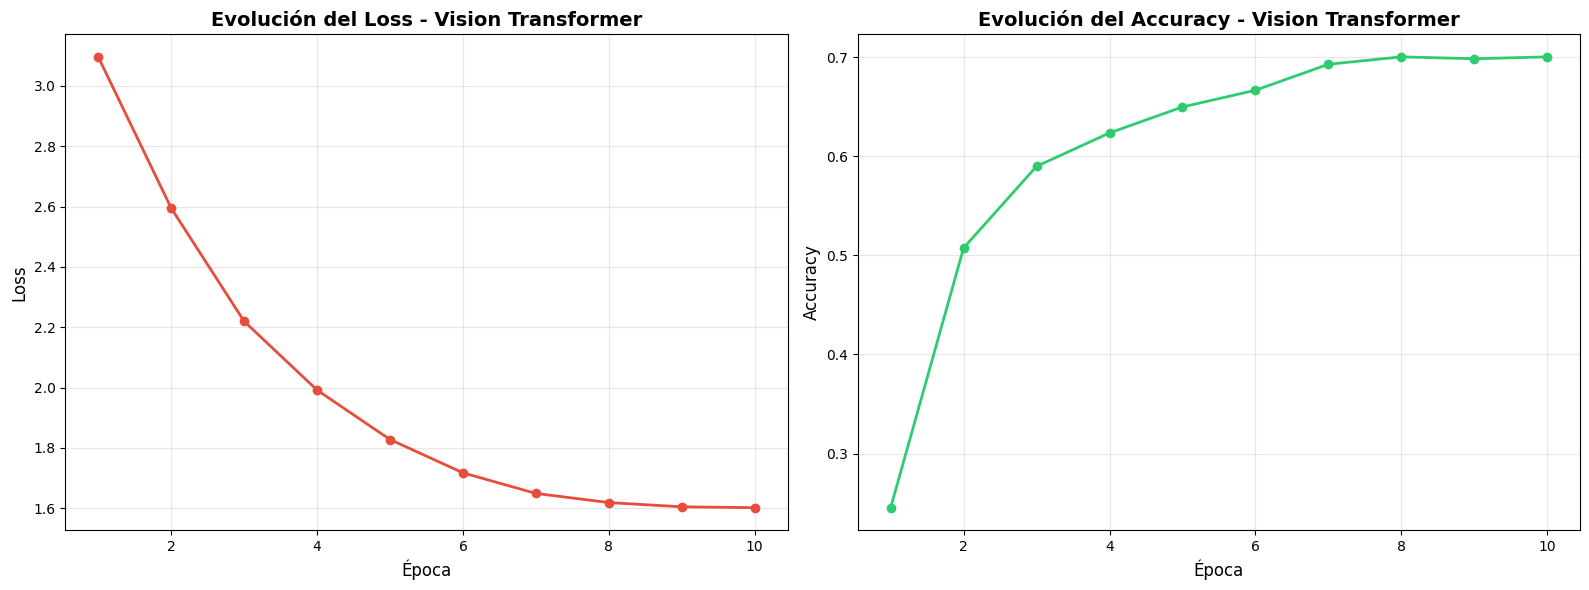


📊 Calculando predicciones...



✅ ACCURACY FINAL: 0.7004 (70.04%)

🔥 Generando matriz de confusión...


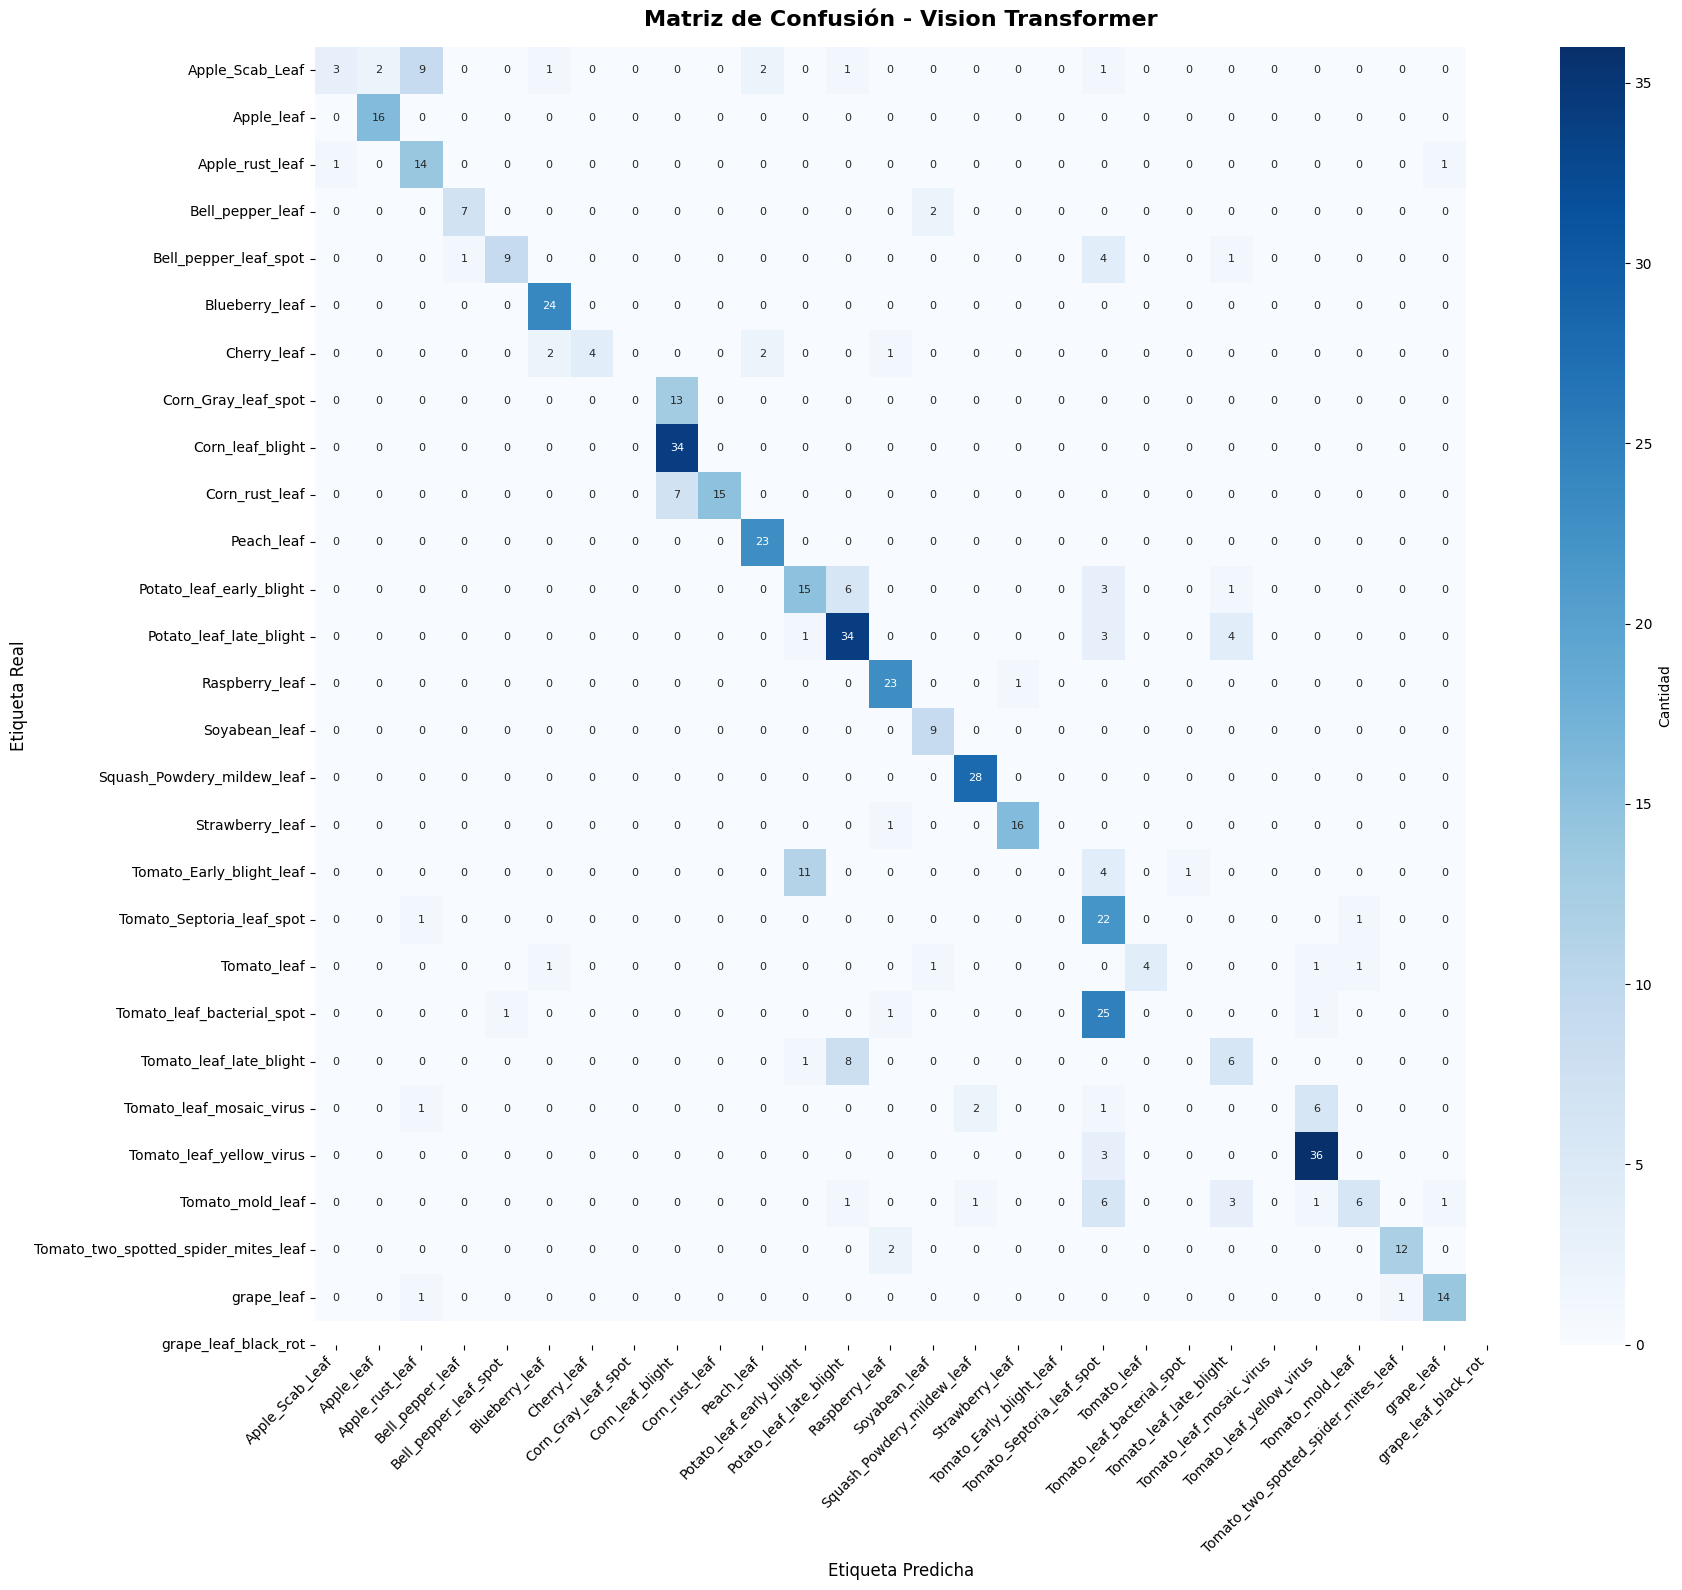


✅ Evaluación completada para: Vision Transformer
   • Accuracy: 0.7004 (70.04%)
   • Total muestras validación: 534
   • Predicciones correctas: 374
   • Predicciones incorrectas: 160



In [109]:
# EVALUACIÓN COMPLETA DEL MODELO ViT

def evaluar_vit_completo(trainer, hf_val_dataset, class_names, model_name="Vision Transformer"):
    """
    Evaluación completa adaptada para ViT
    """
    print("\n" + "="*80)
    print(f"EVALUACIÓN COMPLETA: {model_name}")
    print("="*80 + "\n")

    # ========================================================================
    # CURVAS DE APRENDIZAJE
    # ========================================================================

    print("📈 Generando curvas de aprendizaje...")

    logs = trainer.state.log_history
    eval_loss = []
    eval_accuracy = []
    epochs = []

    for entry in logs:
        if 'eval_loss' in entry:
            eval_loss.append(entry['eval_loss'])
            eval_accuracy.append(entry.get('eval_accuracy', 0))
            epochs.append(entry['epoch'])

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Loss
    ax1.plot(epochs, eval_loss, 'o-', linewidth=2, color='#e74c3c', markersize=6)
    ax1.set_xlabel('Época', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'Evolución del Loss - {model_name}', fontsize=14, fontweight='bold')
    ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(epochs, eval_accuracy, 'o-', linewidth=2, color='#2ecc71', markersize=6)
    ax2.set_xlabel('Época', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title(f'Evolución del Accuracy - {model_name}', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # PREDICCIONES
    # ========================================================================

    print("\n📊 Calculando predicciones...")

    predictions_output = trainer.predict(hf_val_dataset)
    predictions = np.argmax(predictions_output.predictions, axis=-1)
    true_labels = predictions_output.label_ids

    acc = accuracy_score(true_labels, predictions)

    print(f"\n{'='*60}")
    print(f"✅ ACCURACY FINAL: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*60}\n")

    # ========================================================================
    # MATRIZ DE CONFUSIÓN
    # ========================================================================

    print("🔥 Generando matriz de confusión...")

    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Cantidad'},
                annot_kws={'size': 8})
    plt.title(f'Matriz de Confusión - {model_name}',
              fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Etiqueta Real', fontsize=12)
    plt.xlabel('Etiqueta Predicha', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    # ========================================================================
    # RESUMEN
    # ========================================================================

    print("\n" + "="*80)
    print(f"✅ Evaluación completada para: {model_name}")
    print(f"   • Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   • Total muestras validación: {len(true_labels)}")
    print(f"   • Predicciones correctas: {(true_labels == predictions).sum()}")
    print(f"   • Predicciones incorrectas: {(true_labels != predictions).sum()}")
    print("="*80 + "\n")

    return acc

# EVALUAR
accuracy_vit = evaluar_vit_completo(trainer, hf_val_dataset, class_names, "Vision Transformer")

# PARTE 3: Construcción del software con Gradio y Lime

Vamos a construir un front-end para poder aplicar nuestro modelo de una forma más interactiva y llevar una versión "demo" a producción.

Para ello utilizaremos las librerias gradio y lime.

In [110]:
# Importación de librerias
!pip install -q gradio lime

import gradio as gr
import tensorflow as tf
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [111]:
# 2. Obtener los nombres de las clases en el orden correcto
class_names = train_ds.class_names
print("Las clases son:", class_names)

Las clases son: ['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf', 'Bell_pepper_leaf_spot', 'Blueberry_leaf', 'Cherry_leaf', 'Corn_Gray_leaf_spot', 'Corn_leaf_blight', 'Corn_rust_leaf', 'Peach_leaf', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf', 'Strawberry_leaf', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus', 'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf', 'Tomato_two_spotted_spider_mites_leaf', 'grape_leaf', 'grape_leaf_black_rot']


Para que funcione correctamente el modelo cuandos se carga cualquier imagen (ya sea con muchas hojas, una sola, fondo etc.) debemos modificar esta función `procesay_y_predecir` para que preprocese correctamente la imagen insertada y a limpie lo suficiente para que se parezca a las imagenes del dataset.

In [112]:
# Función de predicción, necesitamos una función que reciba una imagen "cruda", la transfomre y nos diga qué es:
from transformers import ViTImageProcessor, ViTForImageClassification
import torch

# La ruta donde guardaste el modelo tras el entrenamiento
model_path = "/content/drive/MyDrive/Universidad/4) MÁSTER EN DATA SCIENCE, BIG DATA & BUSINESS ANALYTICS (UCM)/TFM/Resultados/vit-final-model"

processor = ViTImageProcessor.from_pretrained(model_path)
model = ViTForImageClassification.from_pretrained(model_path)
model.eval() # Ponemos el modelo en modo lectura

# Obtenemos las clases directamente del modelo
class_names = list(model.config.id2label.values())

def procesar_y_predecir(imagen_numpy):
    if imagen_numpy is None:
        return None

    # 1. Convertir el array de Gradio a imagen PIL
    img_pil = Image.fromarray(imagen_numpy.astype('uint8')).convert('RGB')

    # 2. El procesador hace el Resize(224) y la Normalización automáticamente
    inputs = processor(images=img_pil, return_tensors="pt")

    # 3. Inferencia
    with torch.no_grad():
        outputs = model(**inputs)
        # Convertimos los resultados (logits) en probabilidades (0 a 1)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]

    # 4. Devolver diccionario {Clase: Probabilidad}
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Construcción gradio

In [113]:
# Definimos el tema visual
theme = gr.themes.Soft(
    primary_hue="green",    # Color corporativo para TFM agrícola
    secondary_hue="gray",
    font=[gr.themes.GoogleFont("Poppins"), "ui-sans-serif", "system-ui"]
)

with gr.Blocks(theme=theme, title="PlantHealth AI - ViT") as demo:
    # Cabecera
    gr.Markdown("""
    # 🍃 PlantHealth AI: Diagnóstico por Visión Artificial
    ### Sistema basado en Vision Transformer (ViT) para la detección de patologías vegetales.
    """)

    with gr.Row():
        # Columna Izquierda: Entrada
        with gr.Column(scale=1):
            input_img = gr.Image(
                label="Fotografía de la hoja",
                type="numpy"
            )
            with gr.Row():
                clear_btn = gr.ClearButton([input_img], value="Limpiar")
                submit_btn = gr.Button("🔍 ANALIZAR HOJA", variant="primary")

        # Columna Derecha: Salida
        with gr.Column(scale=1):
            output_label = gr.Label(
                num_top_classes=3,
                label="Probabilidad de Diagnóstico"
            )
            gr.Markdown("""
            **Guía de interpretación:**
            * El modelo analiza texturas y patrones cromáticos.
            * Se muestran los 3 resultados con mayor confianza estadística.
            """)

    # Acción del botón
    submit_btn.click(
        fn=procesar_y_predecir,
        inputs=input_img,
        outputs=output_label
    )

    # Pie de página informativo para el TFM
    gr.Markdown("---")
    gr.Markdown("*Desarrollado como parte del TFM - Máster en Data Science (UCM)*")


/tmp/ipython-input-649529281.py:8: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, title="PlantHealth AI - ViT") as demo:


In [114]:
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://634b5435fba4097125.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.


KeyboardInterrupt: 